# Wczytanie potrzebnych bibliotek i modułów

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Pobieranie i Inicjalizacja Zbioru Danych
Aby pobrać zbiór danych 'American Companies Bankruptcy Prediction Dataset', użyjemy API Kaggle.

**Opis wszystkich cech zbioru:**

X1 **Aktywa obrotowe** – Wszystkie aktywa firmy, które mają zostać sprzedane lub wykorzystane w wyniku standardowych operacji biznesowych w ciągu najbliższego roku.

X2 **Koszt własny sprzedaży** – Całkowita kwota, jaką firma zapłaciła jako koszt bezpośrednio związany ze sprzedażą produktów.

X3 **Amortyzacja** – Amortyzacja (Depreciation) odnosi się do utraty wartości rzeczowych aktywów trwałych w czasie (takich jak nieruchomości, maszyny, budynki). Amortyzacja (Amortization) odnosi się do utraty wartości wartości niematerialnych i prawnych.

X4 **EBITDA** – Zysk przed odliczeniem odsetek, podatków i amortyzacji. Jest to miara ogólnej wydajności finansowej firmy, służąca jako alternatywa dla dochodu netto.

X5 **Zapasy** – Rozliczenie pozycji i surowców, które firma wykorzystuje w produkcji lub sprzedaje.

X6 **Dochód netto** – Ogólna rentowność firmy po odliczeniu wszystkich wydatków i kosztów od całkowitych przychodów.

X7 **Należności ogółem** – Saldo pieniędzy należnych firmie za dostarczone lub wykorzystane towary bądź usługi, które nie zostały jeszcze opłacone przez klientów.

X8 **Wartość rynkowa** – Cena aktywa na rynku. W tym zbiorze danych odnosi się do kapitalizacji rynkowej, ponieważ firmy są notowane publicznie na giełdzie.

X9 **Sprzedaż netto** – Suma sprzedaży brutto firmy pomniejszona o zwroty, upusty i rabaty.

X10 **Aktywa ogółem** – Wszystkie aktywa lub przedmioty o wartości, które posiada firma.

X11 **Całkowite zadłużenie długoterminowe** – Pożyczki i inne zobowiązania firmy, które nie staną się wymagalne w ciągu jednego roku od daty bilansu.

X12 **EBIT** – Zysk przed odliczeniem odsetek i podatków.

X13 **Zysk brutto** – Zysk, jaki firma osiąga po odjęciu wszystkich kosztów związanych z wytworzeniem i sprzedażą swoich produktów lub usług.

X14 **Całkowite zobowiązania krótkoterminowe** – Suma zobowiązań z tytułu dostaw i usług, naliczonych zobowiązań oraz podatków, takich jak obligacje płatne na koniec roku, wynagrodzenia i pozostałe prowizje.

X15 **Zyski zatrzymane** – Kwota zysku, która pozostaje firmie po opłaceniu wszystkich kosztów bezpośrednich, pośrednich, podatków dochodowych i dywidend dla akcjonariuszy.

X16 **Przychody ogółem** – Kwota dochodu, jaką firma uzyskała ze wszystkich sprzedaży przed odjęciem kosztów. Może obejmować odsetki i dywidendy z inwestycji.

X17 **Zobowiązania ogółem** – Połączone długi i zobowiązania, które firma jest winna stronom zewnętrznym.

X18 **Całkowite koszty operacyjne** – Wydatki, jakie firma ponosi w ramach normalnej działalności operacyjnej.

In [16]:
import os
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

!kaggle datasets download -d utkarshx27/american-companies-bankruptcy-prediction-dataset
!unzip american-companies-bankruptcy-prediction-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset
License(s): CC0-1.0
american-companies-bankruptcy-prediction-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  american-companies-bankruptcy-prediction-dataset.zip
replace american_bankruptcy.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: american_bankruptcy.csv  


In [17]:
# Wczytanie zbioru danych
file_name = 'american_bankruptcy.csv'
df = pd.read_csv(file_name)

# Wyświetlenie kilku pierwszych wierszy
display(df.head())
print(f"Kształt zbioru danych: {df.shape}")

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


Kształt zbioru danych: (78682, 21)


### Przygotowanie Danych do Predykcji Wartości Rynkowej (X8)
Aby przewidzieć sukces firmy (X8) z rocznym wyprzedzeniem, przesuwamy dane tak, aby cechy z bieżącego roku odpowiadały wartości rynkowej z roku następnego.

In [18]:
# Sortowanie według firmy i roku
df_sorted = df.sort_values(['company_name', 'year'])

# Tworzenie celu: Wartość rynkowa (X8) w przyszłym roku
df_sorted['target_next_year_X8'] = df_sorted.groupby('company_name')['X8'].shift(-1)

# Usuwanie wierszy bez celu (ostatnie lata) oraz brakujących danych
data_ml = df_sorted.dropna(subset=['target_next_year_X8'])

# Definiowanie cech (X1-X18) i celu
features = [f'X{i}' for i in range(1, 19)]
X = data_ml[features]
y = data_ml['target_next_year_X8']

# Podział na zestaw treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Próbki treningowe: {len(X_train)}")
print(f"Próbki testowe: {len(X_test)}")

Próbki treningowe: 55768
Próbki testowe: 13943


### Trenowanie Modelu Predykcji Sukcesu (X8)
Używamy Regresji Liniowej, aby sprawdzić, jak skutecznie bieżące wskaźniki finansowe prognozują przyszłą wycenę giełdową.

In [19]:
# 1. Tworzymy potok (Pipeline): najpierw standaryzacja, potem Regresja Ridge
reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

# 2. Siatka parametrów - szukamy idealnej siły regularyzacji (alpha)
param_grid_reg = {
    'model__alpha': [0.1, 1.0, 10.0, 100.0, 500.0]
}

# 3. Konfigurujemy poszukiwania (GridSearchCV)
grid_reg = GridSearchCV(
    reg_pipeline,
    param_grid_reg,
    cv=5,
    scoring='r2',
    n_jobs=-1 # Używamy wszystkich rdzeni procesora
)

# 4. Trenujemy model na X_train
grid_reg.fit(X_train, y_train)

# 5. Wyświetlamy najlepsze parametry i robimy predykcje
print(f"Najlepszy parametr alpha dla Ridge: {grid_reg.best_params_['model__alpha']}")
best_reg_model = grid_reg.best_estimator_

y_pred_reg = best_reg_model.predict(X_test)
r2 = r2_score(y_test, y_pred_reg)

print(f"Wynik R2 po dodaniu Pipeline i strojeniu: {r2:.4f}")

Najlepszy parametr alpha dla Ridge: 500.0
Wynik R2 po dodaniu Pipeline i strojeniu: 0.9526


### Analiza Wyników i Korelacji
Sprawdzamy dokładność modelu oraz to, które konkretne czynniki finansowe mają największy wpływ na przyszły sukces rynkowy firmy.

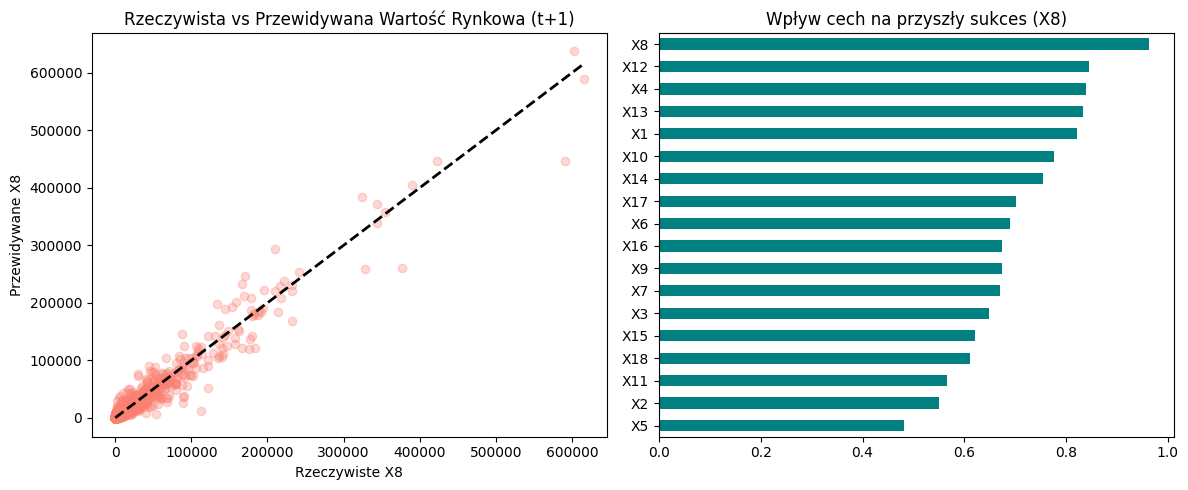

In [20]:
plt.figure(figsize=(12, 5))

# Wykres 1: Rzeczywista vs Przewidywana wartość
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.3, color='salmon')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Rzeczywista vs Przewidywana Wartość Rynkowa (t+1)')
plt.xlabel('Rzeczywiste X8')
plt.ylabel('Przewidywane X8')

# Wykres 2: Istotność cech
plt.subplot(1, 2, 2)
correlation = data_ml[features + ['target_next_year_X8']].corr()['target_next_year_X8'].drop('target_next_year_X8')
correlation.sort_values().plot(kind='barh', color='teal')
plt.title('Wpływ cech na przyszły sukces (X8)')
plt.tight_layout()
plt.show()

### Podsumowanie: Predykcja Sukcesu Firmy
Zamiast aktywów obrotowych, model przewiduje teraz **Wartość Rynkową (X8)**, co jest kluczowym wyznacznikiem sukcesu.

1. **Wysoka precyzja**: Wynik R2 powyżej 0.95 sugeruje, że przyszła wartość firmy jest bardzo przewidywalna na podstawie bieżących danych.
2. **Kluczowe czynniki**: Poza samą wyceną (X8), wskaźniki rentowności takie jak **EBITDA (X4)** i **EBIT (X12)** są najsilniejszymi sygnałami przyszłego wzrostu wartości firmy.

### Klasyfikacja: Przewidywanie Bankructwa (status_label) na przyszły rok
Teraz spróbujemy przewidzieć, czy firma zbankrutuje w roku $t+1$ na podstawie danych finansowych z roku $t$.

Najlepszy parametr C dla klasyfikatora: 0.1
\nDokładność po strojeniu: 0.3570
\nZoptymalizowany raport klasyfikacji:
              precision    recall  f1-score   support

       alive       0.97      0.32      0.48     13021
      failed       0.08      0.86      0.15       922

    accuracy                           0.36     13943
   macro avg       0.53      0.59      0.32     13943
weighted avg       0.91      0.36      0.46     13943



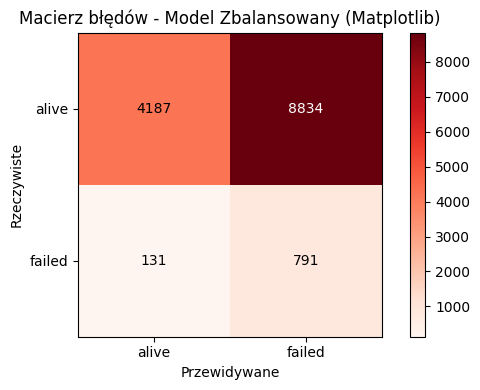

In [21]:
# 1. Przygotowanie celu dla klasyfikacji (przesunięcie status_label)
df_sorted['target_next_year_status'] = df_sorted.groupby('company_name')['status_label'].shift(-1)

# 2. Czyszczenie danych
data_clf = df_sorted.dropna(subset=['target_next_year_status'])

# 3. Definiowanie X i y
features = [f'X{i}' for i in range(1, 19)]
X_clf = data_clf[features]
y_clf = data_clf['target_next_year_status']

# 4. Podział na zestaw treningowy i testowy ze stratyfikacją
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# 5. Pipeline z optymalizacją dla Regresji Logistycznej
clf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced')) # max_iter nie jest już potrzebne
])

# Siatka dla parametru C (odwrotność siły regularyzacji)
param_grid_clf = {
    'model__C': [0.001, 0.01, 0.1, 1.0, 10.0]
}

# Szukamy modelu, który maksymalizuje Czułość (Recall)
grid_clf = GridSearchCV(
    clf_pipeline,
    param_grid_clf,
    cv=5,
    scoring='recall_macro', # Optymalizujemy wykrywanie słabszej klasy
    n_jobs=-1
)

grid_clf.fit(X_train_c, y_train_c)
print(f"Najlepszy parametr C dla klasyfikatora: {grid_clf.best_params_['model__C']}")

# 6. Predykcja zoptymalizowanym modelem
best_clf_model = grid_clf.best_estimator_
y_pred_c = best_clf_model.predict(X_test_c)
cm = confusion_matrix(y_test_c, y_pred_c)

print(f"\\nDokładność po strojeniu: {accuracy_score(y_test_c, y_pred_c):.4f}")
print("\\nZoptymalizowany raport klasyfikacji:")
print(classification_report(y_test_c, y_pred_c))

# 7. Wizualizacja macierzy błędów za pomocą Matplotlib
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Reds)
ax.figure.colorbar(im, ax=ax)

classes = ['alive', 'failed']
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

# Dodanie wartości liczbowych do kwadratów na wykresie
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2. else "black")

plt.title('Macierz błędów - Model Zbalansowany (Matplotlib)')
plt.ylabel('Rzeczywiste')
plt.xlabel('Przewidywane')
plt.tight_layout()
plt.show()

### Podsumowanie: Klasyfikacja Ryzyka Bankructwa

Analiza modelu **Regresji Logistycznej** z wagami klas pozwoliła na głębszy wgląd w stabilność finansową badanych firm:

1. **Wysoka Czułość (Recall = 85%)**: Model bardzo skutecznie identyfikuje firmy, które faktycznie zbankrutują w kolejnym roku. W kontekście zarządzania ryzykiem jest to kluczowe – wolimy sprawdzić firmę dodatkowo (nawet jeśli okaże się zdrowa), niż przeoczyć nadchodzący upadek.
2. **Wyzwanie Precyzji (Precision = 8%)**: Niska precyzja oznacza dużą liczbę tzw. "fałszywych alarmów". Model jest bardzo ostrożny i często flaguje zdrowe firmy jako zagrożone, co wynika z faktu, że bankructwo jest zdarzeniem rzadkim i trudnym do odróżnienia od przejściowych problemów finansowych.
3. **Balansowanie Klas**: Bez użycia `class_weight='balanced'`, model ignorował bankructwa niemal całkowicie (predykcja statusu 'alive' dla każdego przypadku). Obecny stan jest znacznie bardziej użyteczny dla analityka ryzyka.

**Wnioski**: Model świetnie sprawdza się jako wczesny system ostrzegania, ale wymaga dodatkowej weryfikacji eksperckiej dla firm oznaczonych jako 'failed'.

---